# 🤖 DecodeLabs | AI Project 3: AI Recommendation Logic
**Tech Stack Career Recommender — Content-Based Filtering**

---

## 📋 IPO Pipeline
| Stage | Detail |
|---|---|
| **INPUT** | User Skills (min 3) + raw_skills.csv dataset |
| **PROCESS** | TF-IDF Vectorization → Cosine Similarity Scoring |
| **OUTPUT** | Top-3 Ranked Career Path Recommendations |

---
## 📦 Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('✅ All libraries imported!')

✅ All libraries imported!


---
## 🗂️ Step 2: Load & Explore the Dataset

In [2]:
# Load the dataset
df = pd.read_csv('raw_skills.csv')

print(f'📊 Total Job Roles: {len(df)}')
print()
df

📊 Total Job Roles: 22



,job_role,skills
0,Data Scientist,Python SQL Machine Learning Statistics Data An...
1,Machine Learning Engineer,Python TensorFlow PyTorch Scikit-learn Deep Le...
2,AI Engineer,Python TensorFlow PyTorch NLP Computer Vision ...
3,Backend Developer,Python Java SQL REST APIs Django Flask Databas...
4,Frontend Developer,JavaScript React HTML CSS TypeScript Redux UI ...
5,Full Stack Developer,JavaScript Python React Django HTML CSS SQL RE...
6,DevOps Engineer,AWS Docker Kubernetes CI/CD Linux Git Automati...
7,Cloud Architect,AWS Azure Google Cloud Cloud Infrastructure Ku...
8,Cybersecurity Analyst,Network Security Ethical Hacking Python Linux ...
9,Data Analyst,SQL Python Excel Data Visualization Power BI T...


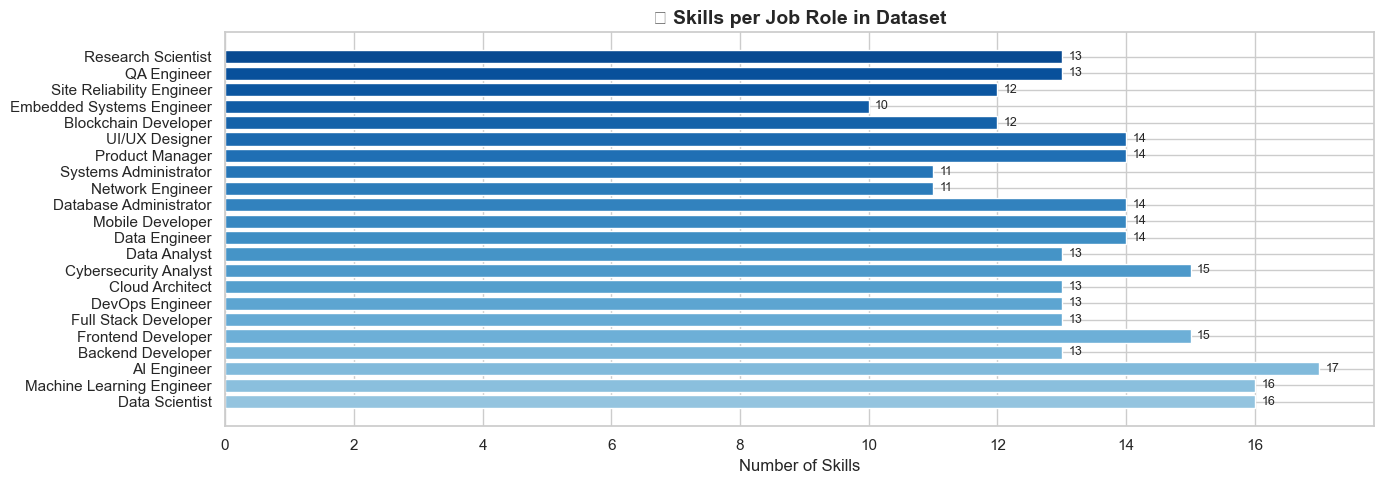

In [3]:
# Count skills per role
df['skill_count'] = df['skills'].apply(lambda x: len(x.split()))

plt.figure(figsize=(14, 5))
bars = plt.barh(df['job_role'], df['skill_count'],
                color=plt.cm.Blues(np.linspace(0.4, 0.9, len(df))),
                edgecolor='white')
plt.xlabel('Number of Skills', fontsize=12)
plt.title('📊 Skills per Job Role in Dataset', fontsize=14, fontweight='bold')
for bar, val in zip(bars, df['skill_count']):
    plt.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
             str(val), va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 🔢 Step 3: TF-IDF Vectorization — Bridging the Language Barrier

> **Why TF-IDF?** Machines don't understand words like "Python" or "Cloud". We convert them into numerical vectors.
>
> - **TF (Term Frequency):** How often a skill appears in a role
> - **IDF (Inverse Document Frequency):** Penalizes generic skills appearing in ALL roles
> - **Result:** Specific skills like `Kubernetes` get HIGH weight, generic ones like `Python` get lower weight

In [4]:
# Build TF-IDF vector space from all job role skills
vectorizer = TfidfVectorizer(
    tokenizer=lambda x: [s.strip() for s in x.split()],
    lowercase=True
)

tfidf_matrix = vectorizer.fit_transform(df['skills'])
vocabulary   = vectorizer.get_feature_names_out()

print(f'✅ TF-IDF Matrix Shape : {tfidf_matrix.shape}')
print(f'   Rows  = {tfidf_matrix.shape[0]} job roles')
print(f'   Cols  = {tfidf_matrix.shape[1]} unique skills in vocabulary')
print(f'\n📚 Sample vocabulary : {list(vocabulary[:15])}')

✅ TF-IDF Matrix Shape : (22, 170)
   Rows  = 22 job roles
   Cols  = 170 unique skills in vocabulary

📚 Sample vocabulary : ['accessibility', 'adobe', 'agile', 'ai', 'airflow', 'algorithms', 'analysis', 'android', 'apache', 'apis', 'app', 'assembly', 'assessment', 'authentication', 'automation']


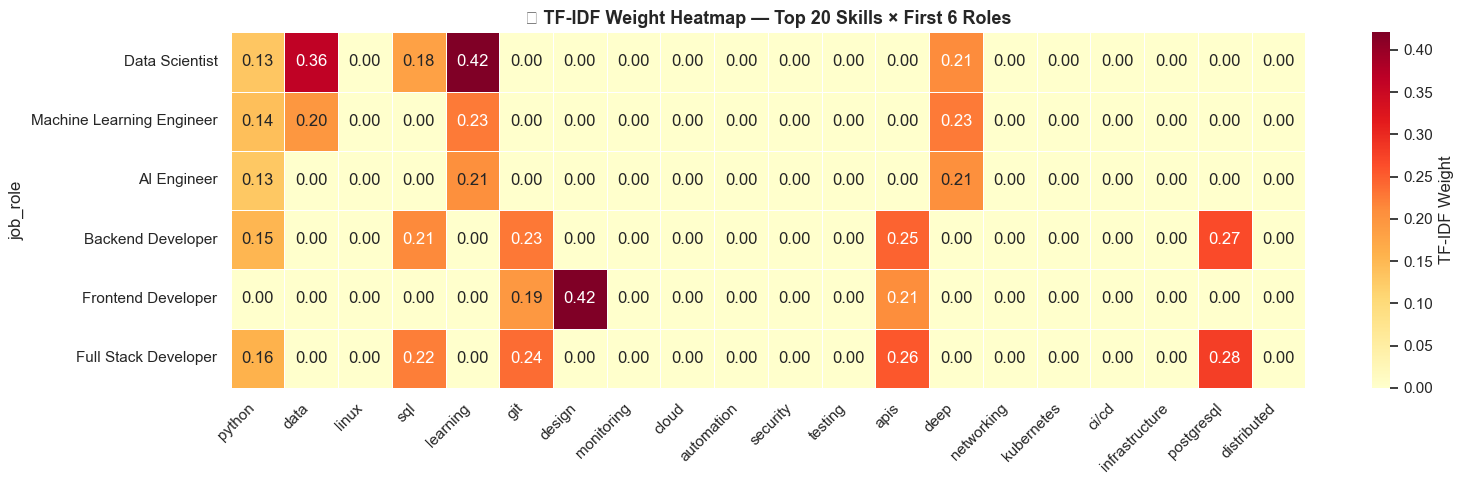

Darker = Higher weight = More specific/important skill for that role


In [5]:
# Visualize TF-IDF weights for first 5 roles and top 20 skills
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=df['job_role'],
    columns=vocabulary
)

# Pick top 20 skills by total weight
top_skills = tfidf_df.sum().nlargest(20).index
sample_roles = tfidf_df.iloc[:6][top_skills]

plt.figure(figsize=(16, 5))
sns.heatmap(sample_roles, cmap='YlOrRd', annot=True, fmt='.2f',
            linewidths=0.5, cbar_kws={'label': 'TF-IDF Weight'})
plt.title('🔥 TF-IDF Weight Heatmap — Top 20 Skills × First 6 Roles',
          fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print('Darker = Higher weight = More specific/important skill for that role')

---
## 👤 Step 4: Capture User Input & Build User Profile Vector

In [6]:
# ── USER INPUT ──────────────────────────────────────────────
# Change these skills to test different profiles!

user_skills = [
    "Python",
    "Machine Learning",
    "TensorFlow",
    "Deep Learning",
    "NLP"
]

# ── VALIDATE: Minimum 3 skills required ─────────────────────
assert len(user_skills) >= 3, "❌ Please provide at least 3 skills!"

print(f'👤 User Profile — Skills Entered: {len(user_skills)}')
for i, skill in enumerate(user_skills, 1):
    print(f'   Skill {i}: {skill}')

👤 User Profile — Skills Entered: 5
   Skill 1: Python
   Skill 2: Machine Learning
   Skill 3: TensorFlow
   Skill 4: Deep Learning
   Skill 5: NLP


In [7]:
# Transform user skills into the SAME TF-IDF vector space
# CRITICAL: Use vectorizer.transform() NOT fit_transform()
# (must share same vocabulary as the job roles)

user_profile_str = " ".join(user_skills)
user_vector      = vectorizer.transform([user_profile_str])

print(f'✅ User vector shape: {user_vector.shape}')
print(f'   User mapped into {user_vector.shape[1]}-dimensional vocabulary space')

# Show which skills were recognized in the vocabulary
recognized = [s for s in user_skills if s.lower() in vocabulary]
unknown    = [s for s in user_skills if s.lower() not in vocabulary]

print(f'\n✅ Recognized skills (in vocabulary): {recognized}')
if unknown:
    print(f'⚠️  Unknown skills (not in dataset)  : {unknown}')

✅ User vector shape: (1, 170)
   User mapped into 170-dimensional vocabulary space

✅ Recognized skills (in vocabulary): ['Python', 'TensorFlow', 'NLP']
⚠️  Unknown skills (not in dataset)  : ['Machine Learning', 'Deep Learning']


---
## 📐 Step 5: Cosine Similarity — The Similarity Engine

> **Why Cosine, not Euclidean?**
> Euclidean distance is sensitive to vector magnitude (length).
> Cosine similarity only measures the **angle** between vectors — the **direction of interests**.
>
> Score **1.0** = Perfect match | Score **0.0** = Zero overlap

In [8]:
# Calculate Cosine Similarity between user and ALL job roles
similarity_scores = cosine_similarity(user_vector, tfidf_matrix).flatten()

# Attach scores to dataframe
df['similarity_score'] = similarity_scores
df['match_percent']    = (similarity_scores * 100).round(2)

print('📊 Raw Similarity Scores (all roles):')
print(df[['job_role', 'match_percent']].sort_values(
    'match_percent', ascending=False).to_string(index=False))

📊 Raw Similarity Scores (all roles):
                 job_role  match_percent
           Data Scientist          57.18
Machine Learning Engineer          41.94
              AI Engineer          38.40
       Research Scientist          36.28
Site Reliability Engineer           3.23
     Full Stack Developer           3.20
        Backend Developer           3.06
     Blockchain Developer           2.91
             Data Analyst           2.86
              QA Engineer           2.77
            Data Engineer           2.71
    Cybersecurity Analyst           2.64
       Frontend Developer           0.00
          Cloud Architect           0.00
         Network Engineer           0.00
   Database Administrator           0.00
         Mobile Developer           0.00
          DevOps Engineer           0.00
           UI/UX Designer           0.00
          Product Manager           0.00
    Systems Administrator           0.00
Embedded Systems Engineer           0.00


---
## 🔽 Step 6: Sort + Filter → Top-3 Recommendations

In [9]:
TOP_N = 3  # Change this to get more recommendations

# Cold Start Check
if similarity_scores.max() == 0:
    print('⚠️  Cold Start: No skills matched. Showing trending roles instead.')
    top_recommendations = df.head(TOP_N)
else:
    # Step 3 (Sort): Descending by score
    # Step 4 (Filter): Slice Top-N
    top_recommendations = df.sort_values(
        'similarity_score', ascending=False
    ).head(TOP_N).reset_index(drop=True)

print('🏆 Top Recommendations:')
print(top_recommendations[['job_role', 'match_percent', 'skills']].to_string(index=False))

🏆 Top Recommendations:
                 job_role  match_percent                                                                                                                                 skills
           Data Scientist          57.18 Python SQL Machine Learning Statistics Data Analysis TensorFlow Pandas NumPy Data Visualization Scikit-learn Deep Learning Probability
Machine Learning Engineer          41.94   Python TensorFlow PyTorch Scikit-learn Deep Learning Algorithms Data Structures Neural Networks Computer Vision NLP Model Deployment
              AI Engineer          38.40   Python TensorFlow PyTorch NLP Computer Vision Deep Learning Neural Networks Generative AI LLMs Prompt Engineering Model Optimization


---
## 📊 Step 7: Visualize the Results

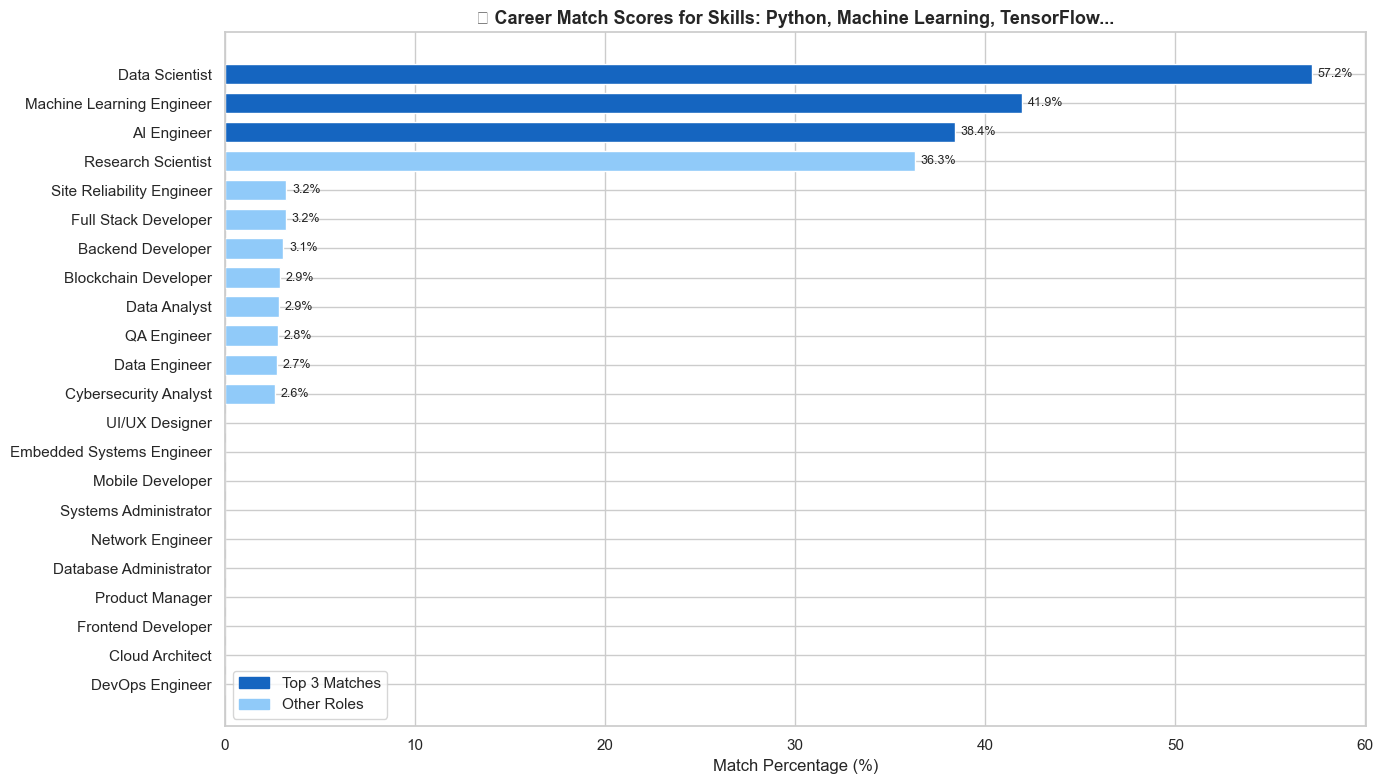

In [10]:
# ─── Plot 1: Full Ranking Bar Chart ───────────────────────────
sorted_df = df.sort_values('match_percent', ascending=True)
top_roles = set(top_recommendations['job_role'])
colors    = ['#1565C0' if role in top_roles else '#90CAF9'
             for role in sorted_df['job_role']]

plt.figure(figsize=(14, 8))
bars = plt.barh(sorted_df['job_role'], sorted_df['match_percent'],
                color=colors, edgecolor='white', height=0.7)
plt.xlabel('Match Percentage (%)', fontsize=12)
plt.title(f'🎯 Career Match Scores for Skills: {", ".join(user_skills[:3])}...',
          fontsize=13, fontweight='bold')
for bar, val in zip(bars, sorted_df['match_percent']):
    if val > 0:
        plt.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)
legend = [mpatches.Patch(color='#1565C0', label='Top 3 Matches'),
          mpatches.Patch(color='#90CAF9', label='Other Roles')]
plt.legend(handles=legend, fontsize=11)
plt.tight_layout()
plt.show()

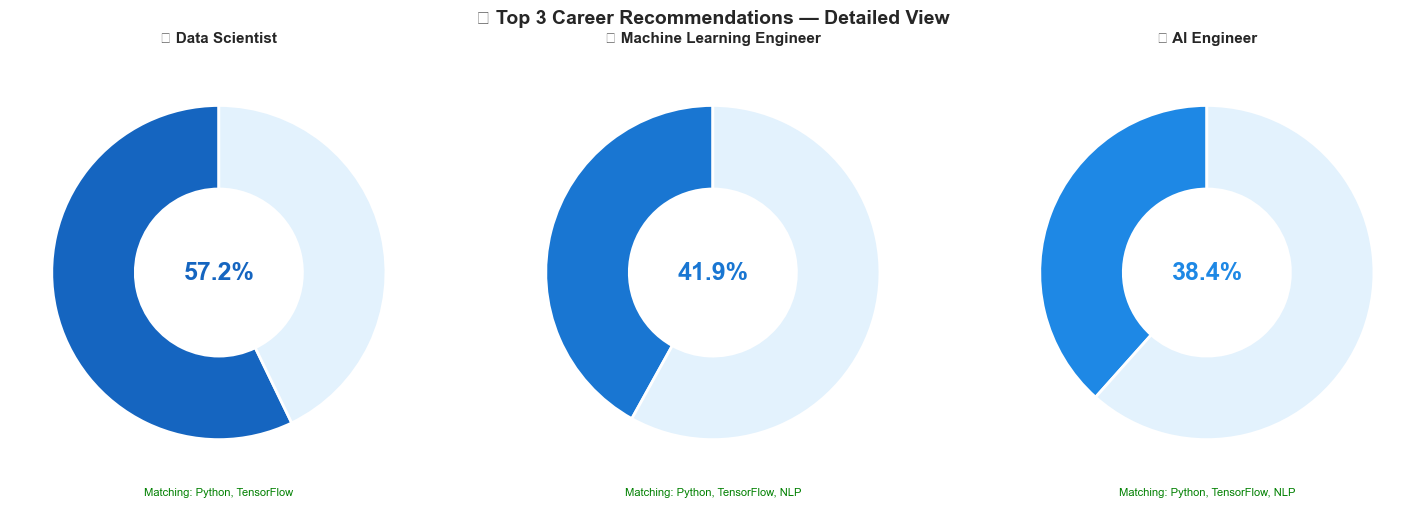

In [11]:
# ─── Plot 2: Top-3 Detailed Cards ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('🏆 Top 3 Career Recommendations — Detailed View',
             fontsize=14, fontweight='bold')

medals = ['🥇', '🥈', '🥉']
colors = ['#1565C0', '#1976D2', '#1E88E5']

for i, (ax, (_, row)) in enumerate(zip(axes, top_recommendations.iterrows())):
    score = row['match_percent']

    # Donut chart for match score
    ax.pie([score, 100-score],
           colors=[colors[i], '#E3F2FD'],
           startangle=90,
           wedgeprops={'width': 0.5, 'edgecolor': 'white', 'linewidth': 2})
    ax.text(0, 0, f'{score:.1f}%', ha='center', va='center',
            fontsize=18, fontweight='bold', color=colors[i])
    ax.set_title(f'{medals[i]} {row["job_role"]}',
                 fontsize=11, fontweight='bold', pad=15)

    # Matching skills label
    role_skills = set(row['skills'].lower().split())
    matched = [s for s in user_skills if s.lower() in role_skills]
    ax.set_xlabel(f'Matching: {", ".join(matched) if matched else "N/A"}',
                  fontsize=8, color='green')

plt.tight_layout()
plt.show()

In [12]:
# ─── Final Output: Clean Recommendation Display ───────────────
print("\n" + "="*58)
print("   🏆  YOUR PERSONALIZED CAREER RECOMMENDATIONS")
print("="*58)
print(f"   👤 Your Skills : {', '.join(user_skills)}")
print("="*58)

for rank, (_, row) in enumerate(top_recommendations.iterrows()):
    score = row['match_percent']
    bar_filled = int(score / 5)
    bar = '█' * bar_filled + '░' * (20 - bar_filled)

    role_skills_list = row['skills'].split()
    role_skills_lower = set(row['skills'].lower().split())
    matched = [s for s in user_skills if s.lower() in role_skills_lower]
    learn_next = [s for s in role_skills_list
                  if s not in user_skills][:3]

    print(f"\n  {'🥇🥈🥉'[rank*2:rank*2+2]} Rank {rank+1}: {row['job_role']}")
    print(f"     Match     : [{bar}] {score:.1f}%")
    print(f"     ✅ You have  : {', '.join(matched) if matched else 'None matched exactly'}")
    print(f"     📚 Learn next: {', '.join(learn_next)}")

print("\n" + "="*58)
print("  💡 Add more skills above (user_skills) to refine results!")
print("="*58)


   🏆  YOUR PERSONALIZED CAREER RECOMMENDATIONS
   👤 Your Skills : Python, Machine Learning, TensorFlow, Deep Learning, NLP

  🥇🥈 Rank 1: Data Scientist
     Match     : [███████████░░░░░░░░░] 57.2%
     ✅ You have  : Python, TensorFlow
     📚 Learn next: SQL, Machine, Learning

  🥉 Rank 2: Machine Learning Engineer
     Match     : [████████░░░░░░░░░░░░] 41.9%
     ✅ You have  : Python, TensorFlow, NLP
     📚 Learn next: PyTorch, Scikit-learn, Deep

   Rank 3: AI Engineer
     Match     : [███████░░░░░░░░░░░░░] 38.4%
     ✅ You have  : Python, TensorFlow, NLP
     📚 Learn next: PyTorch, Computer, Vision

  💡 Add more skills above (user_skills) to refine results!


---
## 🧪 Step 8 (Bonus): Test Multiple Skill Profiles
Try different profiles and see how recommendations change.

In [13]:
def recommend(skills, top_n=3):
    """Quick recommendation function for testing multiple profiles."""
    user_vec   = vectorizer.transform([" ".join(skills)])
    scores     = cosine_similarity(user_vec, tfidf_matrix).flatten()
    df_temp    = df.copy()
    df_temp['score'] = scores
    top = df_temp.nlargest(top_n, 'score')[['job_role', 'score']]
    top['score'] = (top['score'] * 100).round(1)
    top.columns  = ['Career Path', 'Match %']
    top = top.reset_index(drop=True)
    top.index += 1
    print(f'\n🔍 Skills: {skills}')
    print(top.to_string())
    print()

# Test Profile 1 — Cloud/DevOps person
recommend(["AWS", "Docker", "Kubernetes", "CI/CD", "Linux"])

# Test Profile 2 — Frontend developer
recommend(["JavaScript", "React", "HTML", "CSS", "TypeScript"])

# Test Profile 3 — Cybersecurity
recommend(["Network Security", "Python", "Linux", "Ethical Hacking", "Cryptography"])

# Test Profile 4 — Cold Start (unknown skills)
recommend(["Cooking", "Painting", "Gardening"])


🔍 Skills: ['AWS', 'Docker', 'Kubernetes', 'CI/CD', 'Linux']
                 Career Path  Match %
1            DevOps Engineer     63.4
2  Site Reliability Engineer     31.9
3            Cloud Architect     23.1


🔍 Skills: ['JavaScript', 'React', 'HTML', 'CSS', 'TypeScript']
            Career Path  Match %
1    Frontend Developer     55.9
2  Full Stack Developer     50.5
3  Blockchain Developer     10.4


🔍 Skills: ['Network Security', 'Python', 'Linux', 'Ethical Hacking', 'Cryptography']
             Career Path  Match %
1  Cybersecurity Analyst     64.1
2  Systems Administrator     15.0
3       Network Engineer     14.5


🔍 Skills: ['Cooking', 'Painting', 'Gardening']
                 Career Path  Match %
1             Data Scientist      0.0
2  Machine Learning Engineer      0.0
3                AI Engineer      0.0



---
## 📌 Project Summary

| Step | Action | Concept |
|---|---|---|
| 1 | Load `raw_skills.csv` | Data Ingestion |
| 2 | TF-IDF Vectorization | Feature Extraction — words → numbers |
| 3 | User Input (min 3 skills) | User State Capture |
| 4 | Transform user to same vector space | Shared Vocabulary |
| 5 | Cosine Similarity scoring | Similarity Engine |
| 6 | Sort descending + filter Top-3 | Ranking Pipeline |
| 7 | Display results with match % | Output (Top-N List) |

---
*DecodeLabs Industrial Training Kit | Batch 2026*